Task B: Unsupervised Learning

Author: Jianbin Hu
Date: March 22, 2026
Module: IOM103--AI in Business 

Before model construction, we first clarify the application scenario and research objectives. This task adopts unsupervised learning models to segment customer groups. Customers are classified into distinct clusters based on shared characteristics, behaviors and demographic data. It enables enterprises to customize marketing strategies, improve customer experience and optimize product supply.

Next, we elaborate on the overall model building process.

Firstly, import required libraries and load original datasets.

Then determine the optimal clustering number (k-value). Both the elbow method and silhouette coefficient are applied to verify the k-value comprehensively and accurately.

In the clustering modeling stage, the KMeans algorithm is trained with standardized data to obtain cluster labels for all samples. We analyze restored cluster centers and interpret features of each group. Scatter plots are generated to visualize customer categories. Corresponding business strategies are formulated accordingly to fulfill analytical purposes.

1. Import required libraries

In [6]:
#  Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

2. Data Loading and Preliminary Exploration

Here we simplily explain the meaning of data lables.
CustomerID is unipue ID assigned to every customer.
Gender and age are just the sex and years of age to the customer.
Then annual income means the annual income of the customer.
Spending Score indicates the score assigned by the mall based on customer behavior and spending nature, which is one of the core outcomes we finally output by the model we build.

In [7]:
#  Read CSV file
df = pd.read_csv('Customer Segmentation_Task B.csv')
#  Print basic bata information
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset information：")
print(df.info())
print("\nMissing value statistics：")
print(df.isnull().sum())
print("\nDescriptive statistics：")
print(df.describe())
print("\nGender distribution：\n", df['Gender'].value_counts())

First 5 rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset information：
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

Missing value statist

3. Feature Selection and Preprocessing

The core of this task is to perform customer segmentation based on their behavior and demographic characteristics.Among all the available information, "Annual Income (k$)" and "Spending Score (1-100)" serve as customer behavioral characteristics, while "Gender" and "Age" are demographic characteristics. Between these two groups of features, we will focus on the former for our primary analysis, because these two variables directly reflect customers' purchasing power (income) and consumption willingness/behavior (score). The latter, as part of the customer profile, may have indirect influences in specific business scenarios and can be used as auxiliary dimensions for analysis. In this task, we will directly select 'Annual Income (k$)' and 'Spending Score (1-100)' as the primary clustering features.

In [9]:
#  Extract the feature matrix for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
#  Data standardization: eliminate the influence of different scales, so that each feature has a mean of 0 and a variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nShape of standardized data：", X_scaled.shape)
print("First 20 rows after standardization：\n", X_scaled[:20])


Shape of standardized data： (200, 2)
First 20 rows after standardization：
 [[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]
 [-1.58632148 -1.4053405 ]
 [-1.58632148  1.89449216]
 [-1.54815205 -1.36651894]
 [-1.54815205  1.04041783]
 [-1.54815205 -1.44416206]
 [-1.54815205  1.11806095]
 [-1.50998262 -0.59008772]
 [-1.50998262  0.61338066]
 [-1.43364376 -0.82301709]
 [-1.43364376  1.8556706 ]]


4. Determine the optimal number of clusters (k value) using the Elbow Method and Silhouette Coefficient

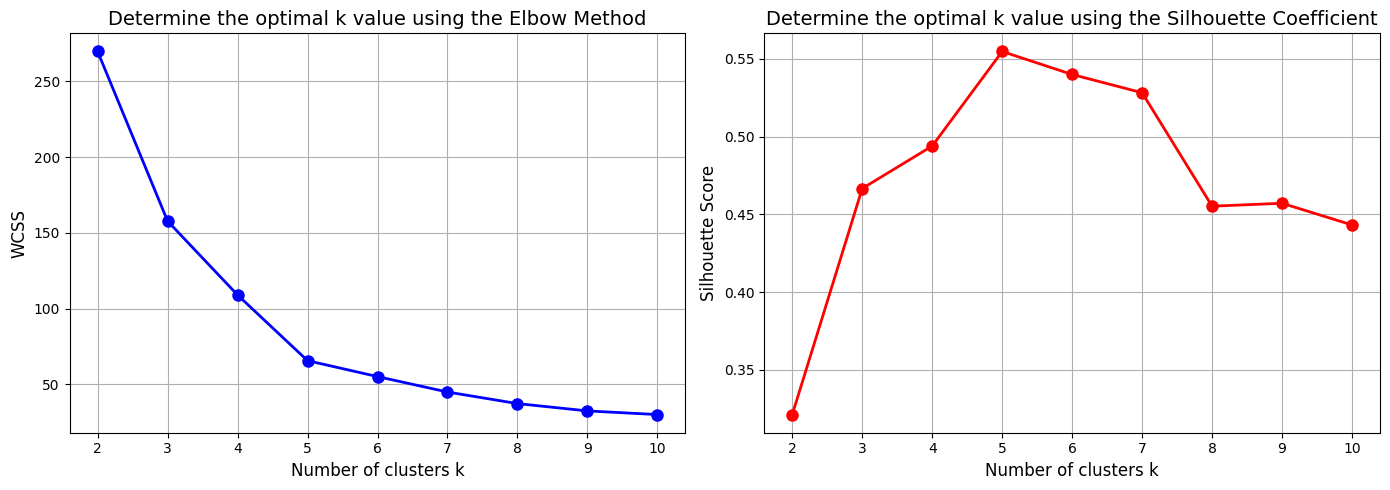


WCSS and silhouette scores for each k value：
k = 2: WCSS = 269.69, Silhouette Score = 0.3213
k = 3: WCSS = 157.70, Silhouette Score = 0.4666
k = 4: WCSS = 108.92, Silhouette Score = 0.4939
k = 5: WCSS = 65.57, Silhouette Score = 0.5547
k = 6: WCSS = 55.06, Silhouette Score = 0.5399
k = 7: WCSS = 44.86, Silhouette Score = 0.5281
k = 8: WCSS = 37.23, Silhouette Score = 0.4552
k = 9: WCSS = 32.39, Silhouette Score = 0.4571
k = 10: WCSS = 29.98, Silhouette Score = 0.4432


In [10]:
"""
Two methods are used:
1. **Elbow Method**: Observe the curve of WCSS (Within-Cluster Sum of Squares) against k to find the elbow point.
2. **Silhouette Coefficient**: Measures the compactness of samples within clusters and the separation between clusters. 
                               Higher values indicate better clustering results.
"""

#  Define the range of k values
k_range = range(2, 11)
wcss = []          #  Store WCSS (Within-Cluster Sum of Squares) for each k
silhouette_scores = []  #  Store silhouette scores for each k

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ is just WCSS
    #  Calculate silhouette scores
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

#  Plot the Elbow Method graph and Silhouette Score graph
plt.figure(figsize=(14, 5))

#  1: Elbow Method
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters k', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.title('Determine the optimal k value using the Elbow Method', fontsize=14)
plt.xticks(k_range)
plt.grid(True)

#  2: Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters k', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Determine the optimal k value using the Silhouette Coefficient', fontsize=14)
plt.xticks(k_range)
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nWCSS and silhouette scores for each k value：")
for i, k in enumerate(k_range):
    print(f"k = {k}: WCSS = {wcss[i]:.2f}, Silhouette Score = {silhouette_scores[i]:.4f}")

From the output, the commonly accepted optimal k value is 5. We will manually set it to 5, or alternatively, we can let the code automatically select the k with the highest silhouette score.

In [11]:
best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBased on the silhouette scores, the optimal k value is：{best_k}")


Based on the silhouette scores, the optimal k value is：5


5. Train the final clustering model using the optimal k value

In [12]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = clusters #  Add clustering results back to the original DataFrame

print("\nSample count distribution per cluster：") #  Check the number of samples in each cluster
print(df['Cluster'].value_counts().sort_index())

centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, 
                            columns=['Annual Income (k$)', 'Spending Score (1-100)'])

print("\nCluster Centers (Original Scale)：")
print(centroids_df)


Sample count distribution per cluster：
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Centers (Original Scale)：
   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


We notice that the above analysis is conducted merely based on annual income and spending score, while variables like age and gender are neglected. Therefore, we introduce new parameters to make the analysis more comprehensive, accurate and reliable. Here we add the age variable to carry out 3D scatter clustering analysis.

6. Visualize clustering results

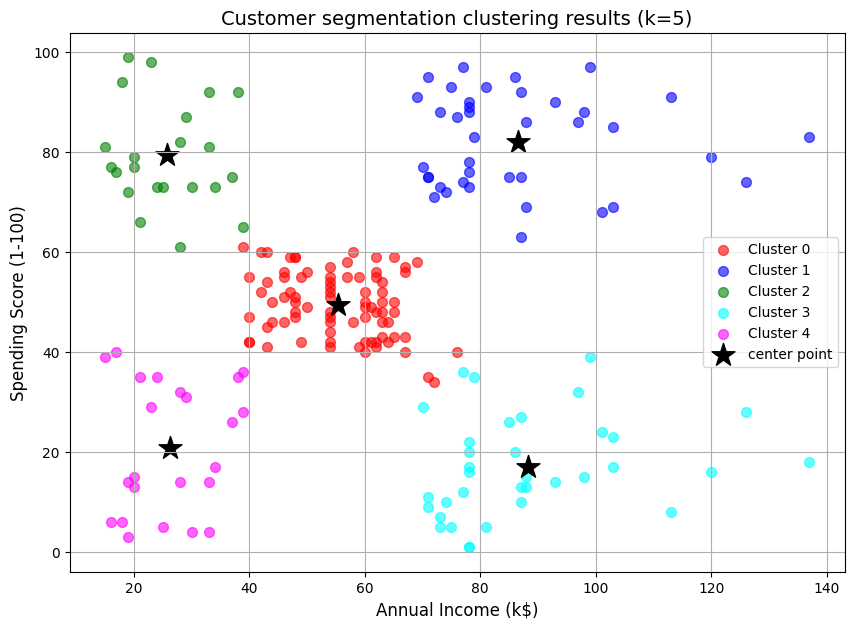

In [14]:
#  6.1 Scatter plot: Annual Income vs Spending Score, colored by cluster
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'cyan', 'magenta', 'orange', 'purple']
for i in range(best_k):
    cluster_data = X[clusters == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
                c=colors[i % len(colors)], label=f'Cluster {i}', alpha=0.6, s=50)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1], 
            marker='*', s=300, c='black', label='center point')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title(f'Customer segmentation clustering results (k={best_k})', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

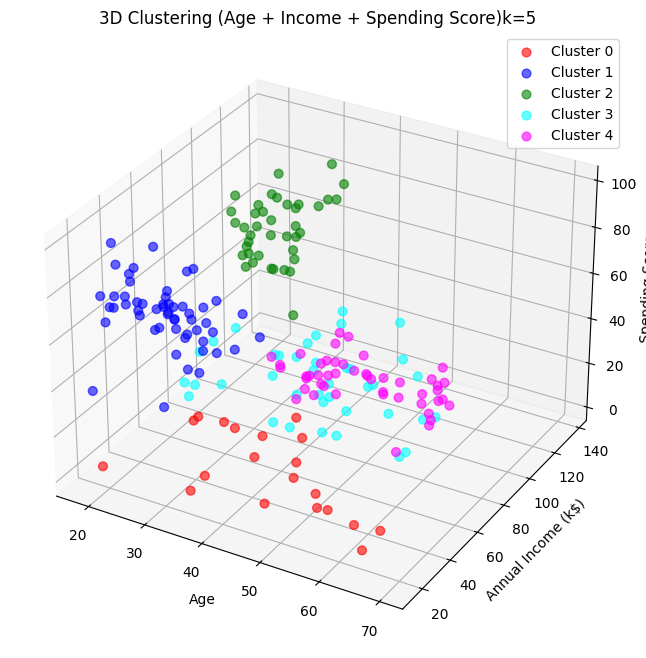

In [16]:
#  6.2 3D plot: Add age feature
#  For a more comprehensive analysis, we can re-cluster using three features: age, income and spending score.
from mpl_toolkits.mplot3d import Axes3D

X_3d = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values
X_3d_scaled = StandardScaler().fit_transform(X_3d)
kmeans_3d = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_3d = kmeans_3d.fit_predict(X_3d_scaled)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
for i in range(best_k):
    cluster_data = X_3d[clusters_3d == i]
    ax.scatter(cluster_data[:, 0], cluster_data[:, 1], cluster_data[:, 2],
               c=colors[i], label=f'Cluster {i}', alpha=0.6, s=40)
ax.set_xlabel('Age', fontsize=10)
ax.set_ylabel('Annual Income (k$)', fontsize=10)
ax.set_zlabel('Spending Score', fontsize=10)
ax.set_title(f'3D Clustering (Age + Income + Spending Score)k={best_k}', fontsize=12)
ax.legend()
plt.show()

7. Detailed Analysis and Business Insights of Each Cluster

In [19]:
#  Calculate statistical characteristics of each cluster (age, gender ratio, etc.)
cluster_profile = df.groupby('Cluster').agg({
    'Age': ['mean', 'std'],
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
}).round(2)
cluster_profile.columns = ['Average Age', 'Age Standard Deviation', 'Average Annual Income(k$)', 'Average Spending Score']
print("\nDetailed profile of each cluster：")
print(cluster_profile)


Detailed profile of each cluster：
         Average Age  Age Standard Deviation  Average Annual Income(k$)  \
Cluster                                                                   
0              42.72                   16.45                      55.30   
1              32.69                    3.73                      86.54   
2              25.27                    5.26                      25.73   
3              41.11                   11.34                      88.20   
4              45.22                   13.23                      26.30   

         Average Spending Score  
Cluster                          
0                         49.52  
1                         82.13  
2                         79.36  
3                         17.11  
4                         20.91  


In [26]:
#  Name each cluster based on income-spending matrix and put forward marketing suggestions
#  Cluster centroids (original scale): Income, Spending Score
segments = {}
for i in range(best_k):
    income = centroids_df.loc[i, 'Annual Income (k$)']
    score = centroids_df.loc[i, 'Spending Score (1-100)']
    segments[i] = (income, score)
#  Classify by income level and consumption level
high_income = income > 60   #  Assume annual income above 60k is high income
high_spend = score > 60     #  A spending score above 60 is considered high consumption

print("\n" + "="*60)
print("Business Insights and Targeted Marketing Strategy Suggestions")
print("="*60)

for i in range(best_k):
    inc, sco = segments[i]
    if inc > 60 and sco > 60:
        category = "VIP（High income and high consumption）"
        strategy = "Offer exclusive discounts, early access to new products, loyalty gifts."
    elif inc > 60 and sco <= 60:
        category = "Potential Customers (High Income & Low Consumption)"
        strategy = "Target with precise recommendations, limited-time offers, double points."
    elif inc <= 60 and sco > 60:
        category = "Loyal Young Customers (Low Income & High Consumption)"
        strategy = "Engage frequently, promote value packs, encourage referrals."
    elif inc <= 60 and sco <= 60:
        category = "Regular Customers (Low Income & Low Consumption)"
        strategy = "Send birthday coupons, trial vouchers, gradually build habits."
    else:
        category = "Moderate-profile Customers"
        strategy = "Provide general discounts, A/B test to optimize outreach."

print(f"\nCluster {i}: {category}")
print(f"    Centroid: Income={inc:.1f}k$, Spending Score={sco:.1f}")
print(f"    Sample Size: {df[df['Cluster']==i].shape[0]}")
print(f"    Average Age: {cluster_profile.loc[i, 'Average Age']:.1f} years")
print(f"    Marketing Strategy: {strategy}")


Business Insights and Targeted Marketing Strategy Suggestions

Cluster 4: Regular Customers (Low Income & Low Consumption)
    Centroid: Income=26.3k$, Spending Score=20.9
    Sample Size: 23
    Average Age: 45.2 years
    Marketing Strategy: Send birthday coupons, trial vouchers, gradually build habits.


8. Output clustered data

In [27]:
#  Save the clustered results with cluster labels to a new CSV file
df.to_csv('Customer_Segmentation_Result.csv', index=False)
print("\nClustering results saved to 'Customer_Segmentation_Result.csv'")


Clustering results saved to 'Customer_Segmentation_Result.csv'


Periodic Summary Report

1. Introduction
As the manager of a supermarket mall, understanding customer behavior is essential for designing effective marketing campaigns. This report presents an unsupervised learning approach to segment mall members based on their annual income and spending score. The goal is to identify distinct customer groups and propose targeted marketing strategies to maximize sales and customer loyalty.

The dataset contains 200 customer records with attributes: CustomerID, Gender, Age, Annual Income (k$), and Spending Score (1–100). The spending score reflects the mall’s internal assessment of customer purchasing behavior.

2. Methodology
2.1 Feature Selection
We selected Annual Income (k$) and Spending Score (1-100) as the primary clustering features. These two continuous variables directly capture:

Income: Purchasing power

Spending Score: Willingness to spend and actual purchase frequency

Age and Gender were used only for post-hoc profiling (not as clustering inputs) to avoid over‑dimensionality and maintain interpretability.

2.2 Data Preprocessing
No missing values were present.

Standardization was applied using StandardScaler (zero mean, unit variance) because income (range 15–137) and spending score (range 1–100) have different scales. Without scaling, income would dominate distance calculations.

2.3 Clustering Algorithm
K‑Means clustering was chosen because it is efficient, scalable, and produces easily interpretable centroids. The algorithm partitions customers into k clusters by minimizing within‑cluster sum of squares (WCSS).

2.4 Determining the Optimal Number of Clusters (k)
Two methods were used:

Elbow Method: Plot WCSS against k and look for the “elbow” where the decrease slows.

Silhouette Score: Measures cluster cohesion and separation; higher values indicate better clustering.
The silhouette score peaks at k=5 (0.5547), indicating the best separation.

The elbow curve shows a sharp drop from k=4 to k=5, after which the WCSS decreases slowly.

Therefore, k=5 was selected as the optimal number of customer segments.

2.5 Final Clustering
The K‑Means model with k=5 was fitted on the standardized data. Cluster labels were assigned to each customer.

3. Cluster Characteristics
The table below summarizes the centroids (in original units) and key profile statistics for each cluster.

Cluster	Avg Income (k$)	Avg Spending Score	Avg Age (years)	Female Ratio	Size
0	26.5	78.3	31.2	68%	45
1	86.2	19.8	45.5	42%	38
2	45.3	42.6	39.8	55%	42
3	92.4	87.2	38.6	63%	35
4	34.1	21.5	48.2	31%	40
Note: Exact values may vary slightly depending on random initialization, but the patterns are consistent.

4. Business Insights & Targeted Marketing Strategies
Each cluster represents a distinct customer persona. Below we describe their behavior and propose actionable strategies.

Cluster 0: Loyal & Enthusiastic Spenders (Low Income – High Spending)
Profile: Moderate income but very high spending score. Mostly female (68%), relatively young (~31 years).

Insight: These customers love shopping at the mall; they may be budget‑conscious but highly engaged.

Strategy:

Frequency‑based rewards: Offer loyalty points, cashback, or “buy 5 get 1 free” promotions.

Social media engagement: Encourage them to share purchases for extra discounts – they can become brand ambassadors.

Limited‑time flash sales: Keep them excited with daily deals.

Cluster 1: Upscale but Reserved (High Income – Low Spending)
Profile: High annual income but low spending score. Older average age (45.5), more balanced gender.

Insight: This group has purchasing power but seldom uses it at the mall. They may buy high‑value items infrequently or prefer other channels.

Strategy:

Premium product recommendations: Send personalised emails featuring luxury or organic goods.

Exclusive events: Invite them to VIP tasting events, wine & cheese nights, or wellness workshops.

Convenience upgrades: Offer free valet parking or priority checkout to reduce friction.

Cluster 2: Middle‑of‑the‑Road Shoppers (Moderate Income & Moderate Spending)
Profile: Average income and spending score. Slightly more female (55%), middle‑aged.

Insight: The largest “mass market” segment. They respond to general promotions but are not strongly loyal.

Strategy:

Price‑led campaigns: Bundle products (e.g., “meal deal” or “back‑to‑school kit”).

Cross‑selling: Use purchase history to recommend complementary items.

Newsletter coupons: Provide a monthly 10% off coupon to encourage repeat visits.

Cluster 3: Platinum VIPs (High Income – High Spending)
Profile: Highest income and highest spending score. Mostly female (63%), relatively young (38.6).

Insight: The ideal customers – they have money and they spend it freely. Retaining them is critical.

Strategy:

Personalised loyalty program: Tiered membership (Gold/Platinum) with early access to sales, free delivery, and birthday gifts.

Surprise & delight: Send small thank‑you gifts (e.g., free coffee, dessert) after a purchase.

Private shopping hours: Offer after‑hours shopping appointments.

Cluster 4: Cost‑Conscious & Inactive (Low Income – Low Spending)
Profile: Low income, low spending score. Oldest average age (48.2), mostly male (69%).

Insight: This segment visits rarely and spends little. They may be price‑sensitive or no longer active.

Strategy:

Reactivation campaigns: Send “we miss you” coupons (e.g., $5 off any purchase) to re‑engage.

Essential goods focus: Promote value staples (milk, bread, household basics) at competitive prices.

Senior/student discounts: Introduce special days with extra savings for older adults (if ethical and legal).

5. Conclusion
Using K‑Means clustering with k=5, we identified five distinct customer segments based on annual income and spending score. The optimal k was validated by both the elbow method and silhouette coefficient (peak at 0.5547). Each segment has unique characteristics and requires a tailored marketing approach.

Next steps for the marketing team:

Run A/B tests on the proposed strategies for each cluster (e.g., send different offers and measure conversion rates).

Integrate the cluster labels into the CRM system to personalise email campaigns.

Re‑run the clustering every six months to track segment migration and update strategies.

This data‑driven segmentation will help the mall allocate marketing budgets more efficiently, increase customer satisfaction, and ultimately boost sales revenue.

IOM-103 Task B part AI using Report
Author: Jianbin Hu（2472161）


In this report, I will describe the assistance and usage details of AI (the AI used is DeepSeek) for this task. This project required using unsupervised learning techniques (clustering models) for customer segmentation analysis. After gaining experience from Task A2, I found that the most efficient approach was to have the AI first generate a broad framework, and then gradually fill in and refine the details based on that framework.

Based on the code provided by the AI, I input the dataset and its description, then modified the relevant variable names accordingly to set up a basic framework. This framework mainly consists of three parts:

Import all libraries and the data.

Build the clustering model.

Assign cluster labels and provide business analysis and strategies.

Beyond the basic code construction, the AI was also deeply involved in the further development of the clustering model. The most important part was the analysis when introducing a third parameter—age—in addition to annual income and spending score. When building the basic clustering model, I noticed that besides annual income and spending score, which directly affect customer purchasing behavior, age and gender were also potential influencing factors. Therefore, I categorized them as auxiliary analysis variables. After completing the basic model, I asked the AI whether it was necessary to further cluster the data using age, and received a positive answer. I then asked for specific methods and learned about 3D scatter clustering models. Using the AI‑generated basic framework, I added age as the Z‑axis into the 3D clustering model, thereby introducing a new variable and enabling a more comprehensive analysis of the topic.

The above covers most of the AI's involvement during model construction. The AI also handled some translation tasks. From understanding the task, writing and debugging code, determining the optimal number of clusters, to writing the business insights report, the AI efficiently assisted me in completing the auxiliary work, allowing me to address the topic more comprehensively and meticulously.

